In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

os.chdir(r"C:\Users\PREM\OneDrive\Desktop\Bluestock_MF_Capstone")
os.makedirs("reports", exist_ok=True)

PROC = Path("data/processed")
RAW  = Path("data/raw")

plt.style.use("seaborn-v0_8")

print("Setup complete!")

Setup complete!


In [2]:
nav_history  = pd.read_csv(PROC / "clean_nav.csv",         parse_dates=["date"])
transactions = pd.read_csv(PROC / "clean_transactions.csv", parse_dates=["transaction_date"])
perf         = pd.read_csv(PROC / "clean_performance.csv")
aum          = pd.read_csv(RAW  / "03_aum_by_fund_house.csv")
sip          = pd.read_csv(RAW  / "04_monthly_sip_inflows.csv")
fund_master  = pd.read_csv(RAW  / "01_fund_master.csv")

print("Files loaded!")

Files loaded!


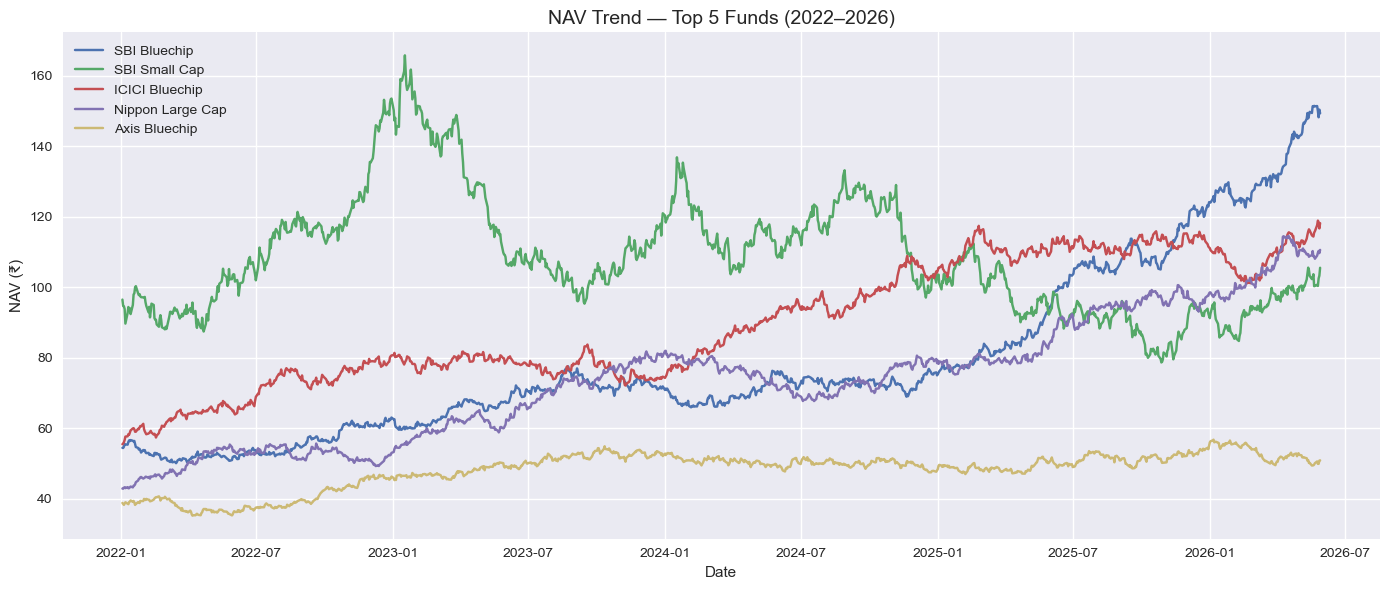

In [3]:
top5 = {
    119551: "SBI Bluechip",
    119599: "SBI Small Cap",
    120503: "ICICI Bluechip",
    118632: "Nippon Large Cap",
    119092: "Axis Bluechip"
}

plt.figure(figsize=(14, 6))
for code, name in top5.items():
    fund_nav = nav_history[nav_history["amfi_code"] == code]
    plt.plot(fund_nav["date"], fund_nav["nav"], label=name)

plt.title("NAV Trend — Top 5 Funds (2022–2026)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("NAV (₹)")
plt.legend()
plt.tight_layout()
plt.savefig("reports/chart1_nav_trend.png")
plt.show()

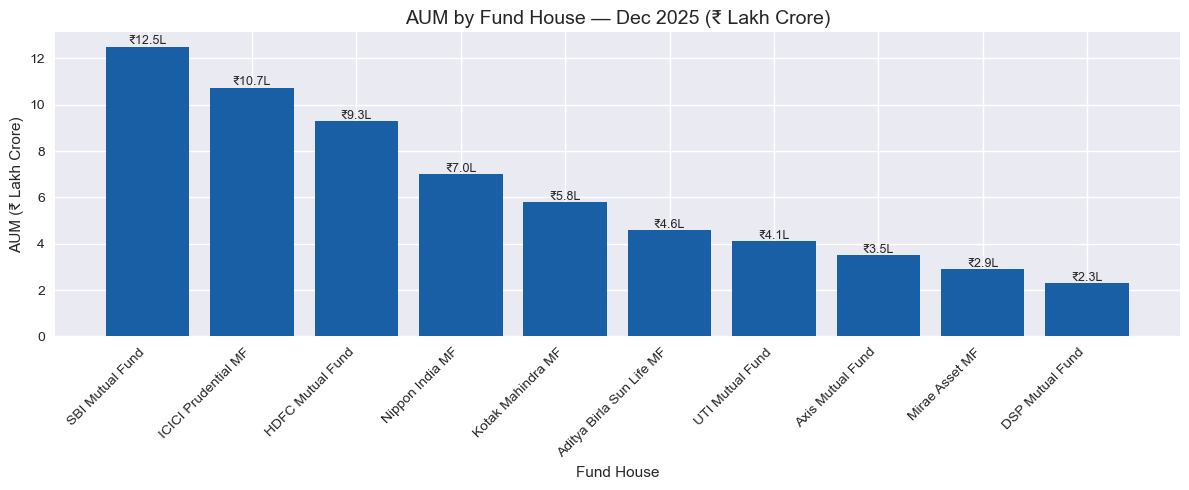

In [4]:
aum["date"]    = pd.to_datetime(aum["date"])
latest_aum     = aum[aum["date"] == aum["date"].max()]
latest_aum     = latest_aum.sort_values("aum_lakh_crore", ascending=False)

plt.figure(figsize=(12, 5))
bars = plt.bar(latest_aum["fund_house"],
               latest_aum["aum_lakh_crore"], color="#185fa5")
plt.title("AUM by Fund House — Dec 2025 (₹ Lakh Crore)", fontsize=14)
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.xticks(rotation=45, ha="right")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.1,
             f"₹{bar.get_height():.1f}L",
             ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("reports/chart2_aum_fund_house.png")
plt.show()

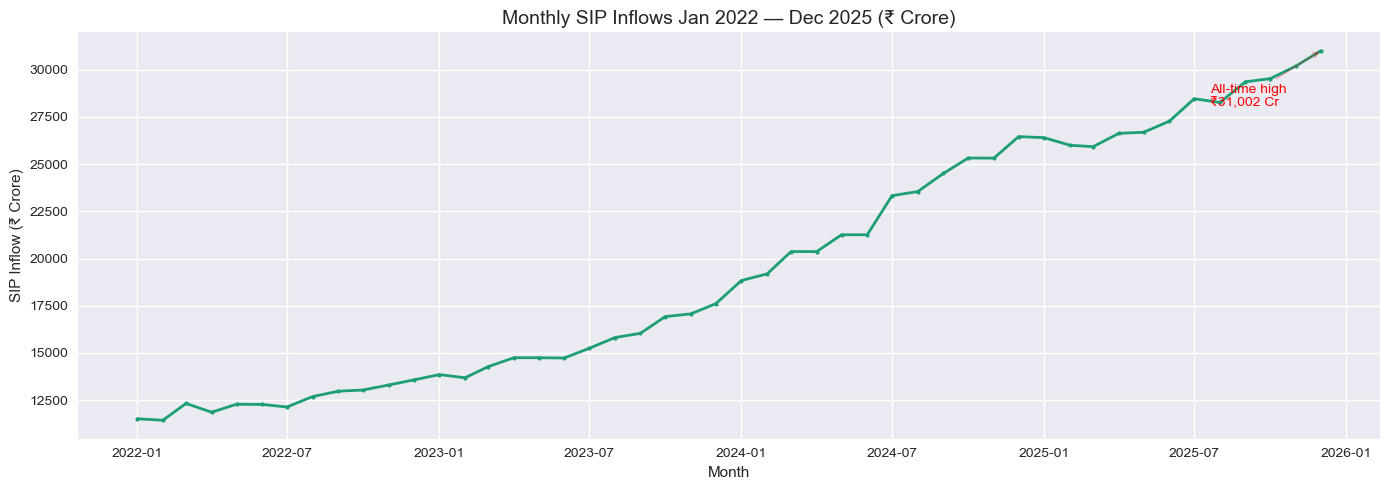

In [5]:
sip["month_dt"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(14, 5))
plt.plot(sip["month_dt"], sip["sip_inflow_crore"],
         color="#1d9e75", linewidth=2, marker="o", markersize=3)

max_idx = sip["sip_inflow_crore"].idxmax()
plt.annotate("All-time high\n₹31,002 Cr",
             xy=(sip.loc[max_idx, "month_dt"],
                 sip.loc[max_idx, "sip_inflow_crore"]),
             xytext=(-80, -40), textcoords="offset points",
             arrowprops=dict(arrowstyle="->", color="red"),
             color="red", fontsize=10)

plt.title("Monthly SIP Inflows Jan 2022 — Dec 2025 (₹ Crore)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")
plt.tight_layout()
plt.savefig("reports/chart3_sip_trend.png")
plt.show()

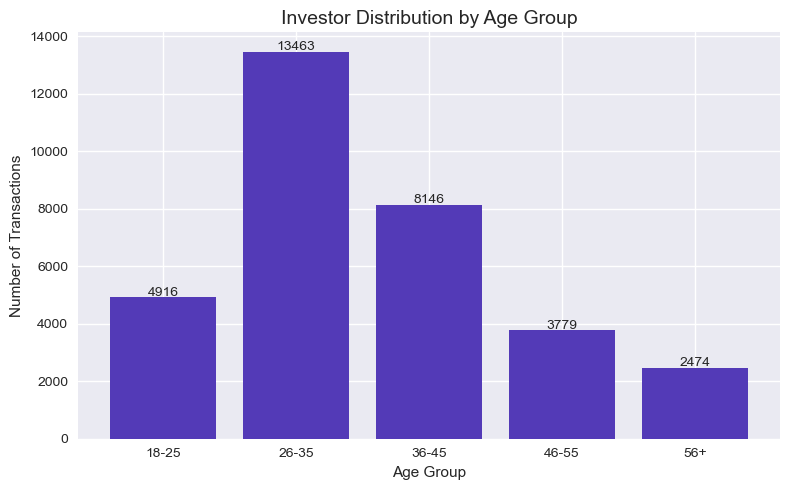

In [6]:
age_counts = transactions["age_group"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(age_counts.index, age_counts.values, color="#533ab7")
plt.title("Investor Distribution by Age Group", fontsize=14)
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 50,
             str(bar.get_height()),
             ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("reports/chart4_age_distribution.png")
plt.show()

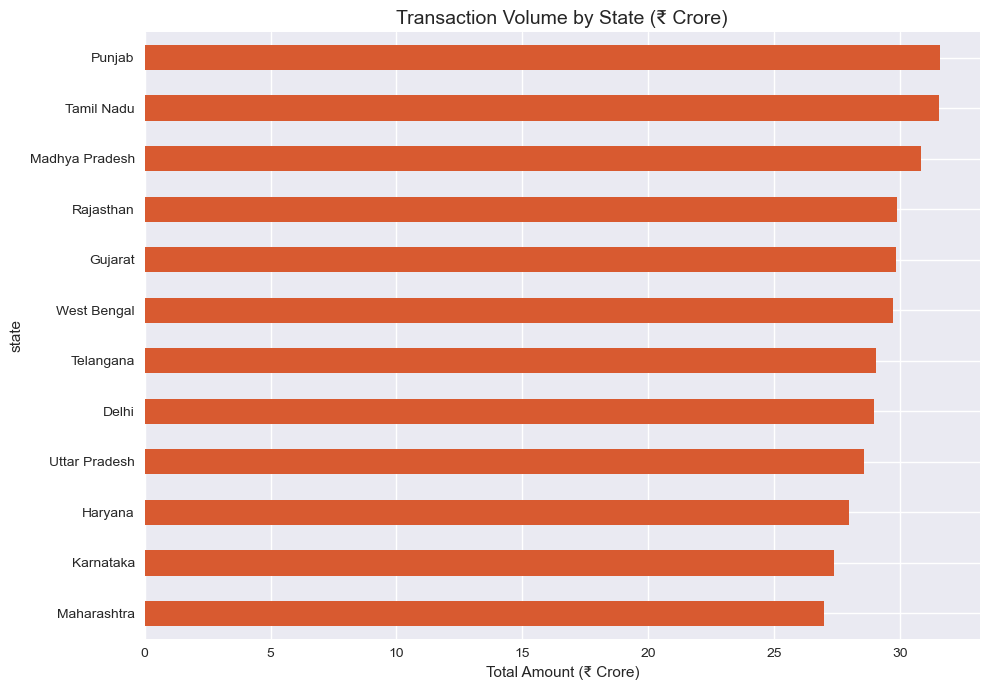

In [7]:
state_vol = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .div(1e7)
    .round(2)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))
state_vol.plot(kind="barh", color="#d85a30")
plt.title("Transaction Volume by State (₹ Crore)", fontsize=14)
plt.xlabel("Total Amount (₹ Crore)")
plt.tight_layout()
plt.savefig("reports/chart5_state_volume.png")
plt.show()

In [8]:
print("=" * 55)
print("KEY EDA FINDINGS")
print("=" * 55)
print(f"1. Largest AMC        : {latest_aum.iloc[0]['fund_house']} ₹{latest_aum.iloc[0]['aum_lakh_crore']}L Cr")
print(f"2. SIP growth         : ₹11,517 Cr → ₹31,002 Cr (+169%)")
print(f"3. Total transactions : {len(transactions):,}")
print(f"4. Top age group      : {age_counts.idxmax()}")
print(f"5. Top state          : {state_vol.idxmax()}")
print(f"6. NAV date range     : {nav_history['date'].min().date()} → {nav_history['date'].max().date()}")
print("=" * 55)

KEY EDA FINDINGS
1. Largest AMC        : SBI Mutual Fund ₹12.5L Cr
2. SIP growth         : ₹11,517 Cr → ₹31,002 Cr (+169%)
3. Total transactions : 32,778
4. Top age group      : 26-35
5. Top state          : Punjab
6. NAV date range     : 2022-01-03 → 2026-05-29
